In [ ]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Drop detection utilities
# ------------------------------------------------------------

def detect_missing_indices(df: pd.DataFrame, fps: float, tolerance_s: float, ts_col="Timestamp") -> list[int]:
    expected_dt = 1.0 / fps
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col], utc=True)
    df = df.sort_values(ts_col).reset_index(drop=True)

    dt = df[ts_col].diff().dt.total_seconds()
    n_dropped_est = np.round(dt / expected_dt - 1).clip(lower=0).astype("Int64")

    drop_events = df[n_dropped_est >= 1]
    missing = []
    for i, k in zip(
        drop_events.index.to_list(),
        n_dropped_est.loc[drop_events.index].astype(int).to_list()
    ):
        missing.extend(range(i + 1, i + 1 + k))

    return missing


def insert_dropped_rows(df: pd.DataFrame, fps: float, missing_idx: list[int], ts_col="Timestamp"):
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col], utc=True)
    df = df.sort_values(ts_col).reset_index(drop=True)
    df["recorded_idx"] = np.arange(len(df), dtype=int)

    expected_dt = pd.to_timedelta(1.0 / fps, unit="s")
    missing_set = set(missing_idx)

    rows = []
    for i in range(len(df)):
        rows.append({
            "global_idx": len(rows),
            "recorded_idx": i,
            ts_col: df.loc[i, ts_col],
            "is_dropped": False,
        })

        if (i + 1) in missing_set:
            k = 0
            j = i + 1
            while j in missing_set:
                k += 1
                j += 1

            last_ts = df.loc[i, ts_col]
            for kk in range(k):
                rows.append({
                    "global_idx": len(rows),
                    "recorded_idx": np.nan,
                    ts_col: last_ts + (kk + 1) * expected_dt,
                    "is_dropped": True,
                })

    filled = pd.DataFrame(rows)

    non_drop = filled["is_dropped"] == False
    other_cols = df.columns.difference([ts_col], sort=False)
    filled.loc[non_drop, other_cols] = df.loc[
        filled.loc[non_drop, "recorded_idx"].astype(int).values,
        other_cols
    ].to_numpy()

    return filled


# ------------------------------------------------------------
# Paths / parameters
# ------------------------------------------------------------

beh_path = r"C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\beh-cam_frame-id_0.csv"
neu_path = r"C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\miniscope_frame-id_0.csv"

fps = 30
tolerance_s = 0.002  # currently unused by detect_missing_indices
tol = pd.Timedelta(seconds=1.0 / fps)  # half-frame tolerance for asof matching


# ------------------------------------------------------------
# Load + fill NEURAL (master timeline)
# ------------------------------------------------------------

neu = pd.read_csv(neu_path)
neu["Timestamp"] = pd.to_datetime(neu["Timestamp"], utc=True)

neu_missing = detect_missing_indices(neu, fps=fps, tolerance_s=tolerance_s, ts_col="Timestamp")
neu_filled  = insert_dropped_rows(neu, fps=fps, missing_idx=neu_missing, ts_col="Timestamp")

# Rename neural columns for clarity and to keep master global index unambiguous
neu_filled = neu_filled.rename(columns={
    "Timestamp": "neu_ts",
    "is_dropped": "neu_dropped",
    "global_idx": "global_idx",   # keep as master name
})

# ------------------------------------------------------------
# Load + fill BEHAVIOR
# ------------------------------------------------------------

beh = pd.read_csv(beh_path)
beh["Timestamp"] = pd.to_datetime(beh["Timestamp"], utc=True)

beh_missing = detect_missing_indices(beh, fps=fps, tolerance_s=tolerance_s, ts_col="Timestamp")
beh_filled  = insert_dropped_rows(beh, fps=fps, missing_idx=beh_missing, ts_col="Timestamp")

# Rename behavior timestamp + drop flag; DROP its global_idx to avoid collisions
beh_filled = beh_filled.rename(columns={
    "Timestamp": "beh_ts",
    "is_dropped": "beh_dropped",
}).drop(columns=["global_idx"], errors="ignore")

# ------------------------------------------------------------
# Strict 1:1 monotonic frame matching (no reuse)
# ------------------------------------------------------------

neu = neu_filled.sort_values("neu_ts").reset_index(drop=True)
beh = beh_filled.sort_values("beh_ts").reset_index(drop=True)
beh["beh_frame_idx"] = np.arange(len(beh))

aligned = neu.copy()
aligned["beh_ts"] = np.nan
aligned["beh_dropped"] = np.nan
aligned["beh_frame_idx"] = np.nan 

i = 0  # neural index
j = 0  # behavior index

tolerance = 1 / fps  # seconds (1 frame window)

matches = 0

while i < len(neu) and j < len(beh):
    dt = (neu.loc[i, "neu_ts"] - beh.loc[j, "beh_ts"]).total_seconds()

    if abs(dt) <= tolerance:
        # match
        aligned.loc[i, "beh_ts"] = beh.loc[j, "beh_ts"]
        aligned.loc[i, "beh_dropped"] = beh.loc[j, "beh_dropped"]
        aligned.loc[i, "beh_frame_idx"] = beh.loc[j, "beh_frame_idx"]
        matches += 1
        i += 1
        j += 1
    elif dt > 0:
        # neural is ahead → behavior behind → move behavior forward
        j += 1
    else:
        # behavior is ahead → neural behind → move neural forward
        i += 1

# ------------------------------------------------------------
# SLEAP data merge 
# ------------------------------------------------------------

sleap = pd.read_csv(r"Z:\Users\May\SLEAP\Miniscope_Model\20260210_1-12-A_20251028.000_beh-cam_0.analysis.csv")
sleap = sleap.rename(columns={"frame_idx": "beh_frame_idx"})

aligned_with_sleap = aligned.merge(
    sleap[["beh_frame_idx", "nose.x", "nose.y", "ear_L.x","ear_L.y","ear_R.x","ear_R.y"]],
    on="beh_frame_idx",
    how="left"
)

aligned_min = aligned_with_sleap[
    [
        "global_idx",
        "neu_ts",
        "beh_ts",
        "neu_dropped",
        "beh_dropped",
        "beh_frame_idx",
        "nose.x",
        "nose.y",
        "ear_L.x",
        "ear_L.y",
        "ear_R.x",
        "ear_R.y",
    ]
].copy()

# COMPUTE HEAD DIRECTION

aligned_min["ear_mid_x"] = (aligned_min["ear_L.x"] + aligned_min["ear_R.x"]) / 2
aligned_min["ear_mid_y"] = (aligned_min["ear_L.y"] + aligned_min["ear_R.y"]) / 2
aligned_min["hd_dx"] = aligned_min["nose.x"] - aligned_min["ear_mid_x"]
aligned_min["hd_dy"] = aligned_min["nose.y"] - aligned_min["ear_mid_y"]

aligned_min["head_dir_rad"] = np.arctan2(
    aligned_min["hd_dy"],
    aligned_min["hd_dx"]
)

valid = aligned_min[["nose.x", "ear_L.x", "ear_R.x"]].notna().all(axis=1)

aligned_min.loc[valid, "head_dir_rad"] = np.arctan2(
    aligned_min.loc[valid, "hd_dy"],
    aligned_min.loc[valid, "hd_dx"]
)

# COMPUTE ANGULAR VELOCITY

out_min = r"C:\Users\psych-aalab\Desktop\aligned_minimal.csv"
aligned_min.to_csv(out_min, index=False)

print(aligned_min.head(20))
print("Neural dropped frames (est):", len(neu_missing))
print("Behavior dropped frames (est):", len(beh_missing))
print("Matched behavior frames:", aligned_min["beh_ts"].notna().sum())
print("Unmatched neural frames:", aligned_min["beh_ts"].isna().sum())
print("Saved minimal to:", out_min)

C:\Users\psych-aalab\AppData\Local\Temp\ipykernel_21280\3797340697.py:144: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-10-28 21:03:44.056153600+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  aligned.loc[i, "beh_ts"] = beh.loc[j, "beh_ts"]
C:\Users\psych-aalab\AppData\Local\Temp\ipykernel_21280\3797340697.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  aligned.loc[i, "beh_dropped"] = beh.loc[j, "beh_dropped"]


    global_idx                              neu_ts  \
0            0    2025-10-28 21:03:43.801088+00:00   
1            1 2025-10-28 21:03:43.828211200+00:00   
2            2 2025-10-28 21:03:43.860979200+00:00   
3            3    2025-10-28 21:03:43.894400+00:00   
4            4 2025-10-28 21:03:43.927180800+00:00   
5            5 2025-10-28 21:03:43.960332800+00:00   
6            6 2025-10-28 21:03:43.993779200+00:00   
7            7 2025-10-28 21:03:44.026483200+00:00   
8            8 2025-10-28 21:03:44.059724800+00:00   
9            9 2025-10-28 21:03:44.092838400+00:00   
10          10 2025-10-28 21:03:44.125798400+00:00   
11          11 2025-10-28 21:03:44.158310400+00:00   
12          12 2025-10-28 21:03:44.191577600+00:00   
13          13    2025-10-28 21:03:44.224960+00:00   
14          14 2025-10-28 21:03:44.258406400+00:00   
15          15 2025-10-28 21:03:44.290777600+00:00   
16          16    2025-10-28 21:03:44.323968+00:00   
17          17 2025-10-28 21

In [5]:
aligned_min


,global_idx,neu_ts,beh_ts,neu_dropped,beh_dropped,beh_frame_idx,nose.x,nose.y,ear_L.x,ear_L.y,ear_R.x,ear_R.y,ear_mid_x,ear_mid_y,hd_dx,hd_dy,head_dir_rad
0,0,2025-10-28 21:03:43.801088+00:00,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-10-28 21:03:43.828211200+00:00,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2025-10-28 21:03:43.860979200+00:00,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2025-10-28 21:03:43.894400+00:00,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2025-10-28 21:03:43.927180800+00:00,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54258,54258,2025-10-28 21:33:38.586790400+00:00,2025-10-28 21:33:38.612505600+00:00,False,False,53837.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54259,54259,2025-10-28 21:33:38.619571200+00:00,2025-10-28 21:33:38.645875200+00:00,False,False,53838.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54260,54260,2025-10-28 21:33:38.652518400+00:00,2025-10-28 21:33:38.679040+00:00,False,False,53839.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54261,54261,2025-10-28 21:33:38.685875200+00:00,2025-10-28 21:33:38.712448+00:00,False,False,53840.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


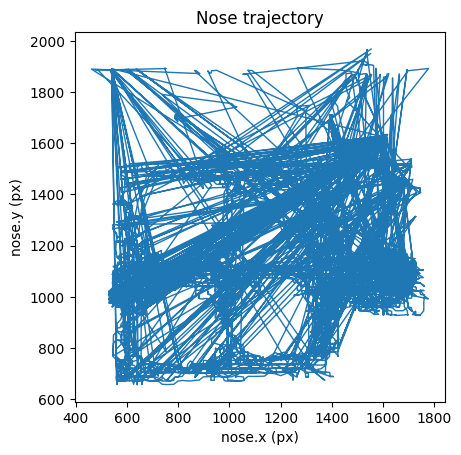

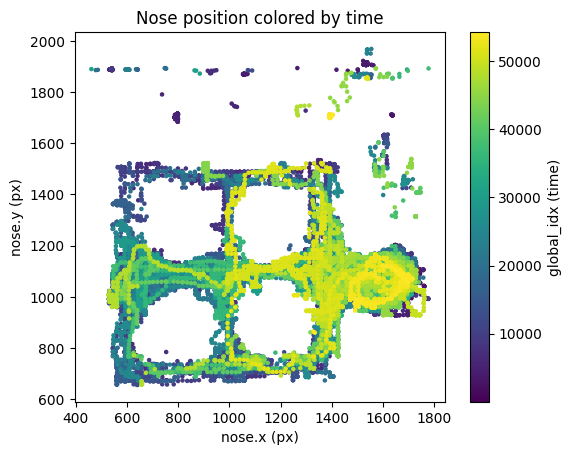

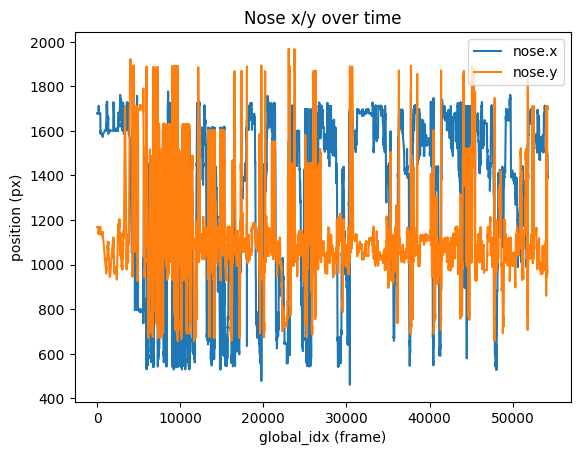

In [6]:
# ------------------------------------------------------------
# Plot nose location (trajectory + time-colored scatter)
# Requires: aligned_min with columns ["nose.x","nose.y","global_idx"]
# ------------------------------------------------------------
import matplotlib.pyplot as plt

# keep only frames where nose coords exist (avoid dropped/untracked frames)
valid = aligned_min[["nose.x", "nose.y"]].notna().all(axis=1)
xy = aligned_min.loc[valid, ["nose.x", "nose.y", "global_idx"]].copy()

# 1) Trajectory line
plt.figure()
plt.plot(xy["nose.x"], xy["nose.y"], linewidth=1)
plt.xlabel("nose.x (px)")
plt.ylabel("nose.y (px)")
plt.title("Nose trajectory")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

# 2) Time-colored scatter (helps spot drift / jumps)
plt.figure()
sc = plt.scatter(xy["nose.x"], xy["nose.y"], c=xy["global_idx"], s=5)
plt.colorbar(sc, label="global_idx (time)")
plt.xlabel("nose.x (px)")
plt.ylabel("nose.y (px)")
plt.title("Nose position colored by time")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

# 3) Nose x/y over time (quick sanity check)
plt.figure()
plt.plot(xy["global_idx"], xy["nose.x"], label="nose.x")
plt.plot(xy["global_idx"], xy["nose.y"], label="nose.y")
plt.xlabel("global_idx (frame)")
plt.ylabel("position (px)")
plt.title("Nose x/y over time")
plt.legend()
plt.show()

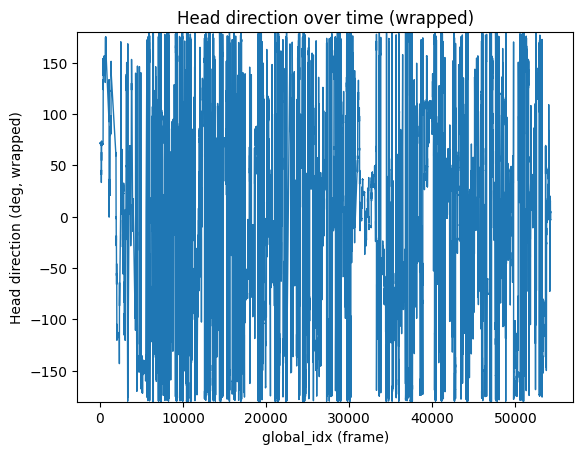

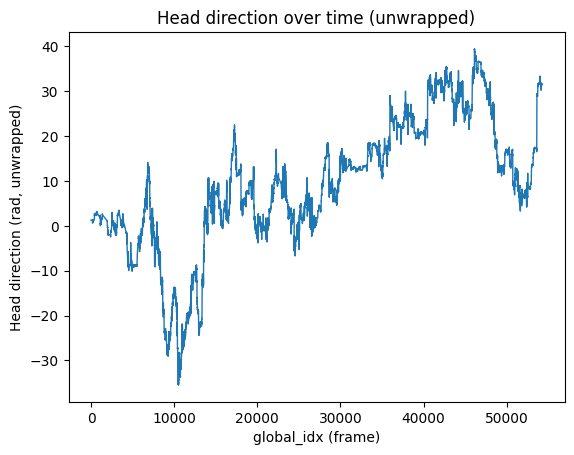

In [7]:
# ------------------------------------------------------------
# Plot head direction over time (degrees) + unwrapped radians
# Requires: aligned_min with columns ["global_idx","head_dir_rad"]
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

df = aligned_min  # you created this in your script

# keep only valid head direction values
valid = df["head_dir_rad"].notna()
x = df.loc[valid, "global_idx"].to_numpy()
hd_rad = df.loc[valid, "head_dir_rad"].to_numpy()

# 1) Wrapped head direction in degrees (-180..180)
hd_deg = np.degrees(hd_rad)

plt.figure()
plt.plot(x, hd_deg, linewidth=1)
plt.xlabel("global_idx (frame)")
plt.ylabel("Head direction (deg, wrapped)")
plt.title("Head direction over time (wrapped)")
plt.ylim(-180, 180)
plt.show()

# 2) Unwrapped head direction in radians (removes ±pi jumps)
hd_unwrapped = np.unwrap(hd_rad)

plt.figure()
plt.plot(x, hd_unwrapped, linewidth=1)
plt.xlabel("global_idx (frame)")
plt.ylabel("Head direction (rad, unwrapped)")
plt.title("Head direction over time (unwrapped)")
plt.show()

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

class ArenaSelector:
    def __init__(self, im):
        self.im = im
        self.points = []
        self.fig, self.ax = plt.subplots()
        self.h = self.ax.imshow(im)
        self.cid = self.fig.canvas.mpl_connect("button_press_event", self.onclick)
        self.ax.set_title("Click to add vertices. Close window when done.")

    def onclick(self, event):
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return
        self.points.append([int(event.xdata), int(event.ydata)])

        # draw polyline preview
        preview = self.im.copy()
        if len(self.points) > 1:
            pts = np.array(self.points, np.int32).reshape((-1, 1, 2))
            cv2.polylines(preview, [pts], False, (0, 255, 0), 2)
        for (x, y) in self.points:
            cv2.circle(preview, (x, y), 3, (255, 0, 0), -1)

        self.h.set_data(preview)
        self.fig.canvas.draw_idle()

    def get_mask(self):
        """Call after you've clicked points."""
        h, w = self.im.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        if len(self.points) >= 3:
            pts = np.array(self.points, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [pts], 255)
        return mask